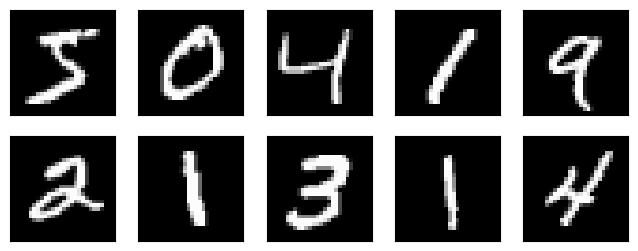

In [1]:
from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib.pyplot as plt

print("Downloading MNIST dataset...")

# 1️⃣ 下载并归一化到 [0,1]（像素级归一化）
X, y = fetch_openml('mnist_784', data_home='./', return_X_y=True, as_frame=False)
X = X.astype(np.float32) / 255.0

# 2️⃣ 显示前10张图片（可选）
plt.figure(figsize=(8, 3))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.xticks([]), plt.yticks([])
plt.show()

# 3️⃣ 取前 1000 张图片
X_small = X[:1000]
y_small = y[:1000]



First 10 image norms after normalization:
[1.         1.         1.         1.         1.0000002  1.0000004
 1.         1.0000002  0.99999994 0.9999998 ]
Saved normalized data to 1k.npz

Number of images per class:
Digit 0: 97 images
Digit 1: 116 images
Digit 2: 99 images
Digit 3: 93 images
Digit 4: 105 images
Digit 5: 92 images
Digit 6: 94 images
Digit 7: 117 images
Digit 8: 87 images
Digit 9: 100 images

Number of digit 2 images: 99


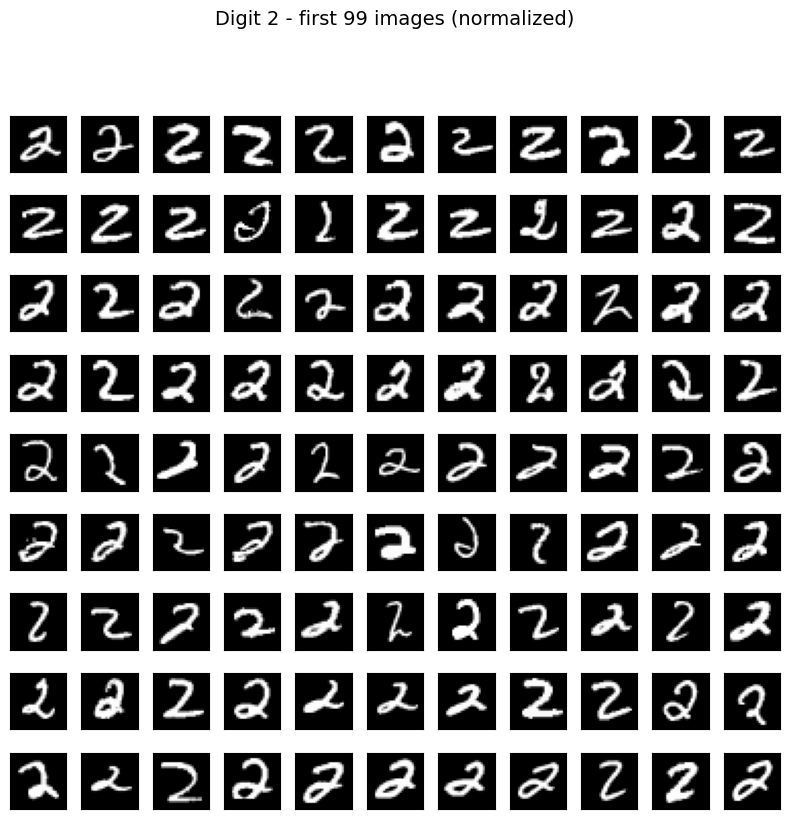

In [2]:
# 4️⃣ ====== 欧几里得归一化（重点新增部分） ======
# 计算每张图片的欧几里得范数
norms = np.linalg.norm(X_small, axis=1, keepdims=True)
norms[norms == 0] = 1  # 防止除以0错误

# 对每张图片除以自己的范数，使其长度为1
X_small_normalized = X_small / norms

# 检查归一化是否成功（前10张图片的范数应为1）
print("First 10 image norms after normalization:")
print(np.linalg.norm(X_small_normalized, axis=1)[:10])
# ==================================================

# 5️⃣ 保存数据（可选）
np.savez('1k.npz', X_small=X_small_normalized, y_small=y_small)
print("Saved normalized data to 1k.npz")

# 6️⃣ 统计每个类别的数量
unique, counts = np.unique(y_small, return_counts=True)
print("\nNumber of images per class:")
for u, c in zip(unique, counts):
    print(f"Digit {u}: {c} images")

# 7️⃣ 找出所有数字2的索引
index = np.nonzero(y_small == '2')[0]
print(f"\nNumber of digit 2 images: {len(index)}")

# 8️⃣ 可视化前99张数字2（使用归一化后的数据）
plt.figure(figsize=(8, 8))
for i in range(99):
    plt.subplot(9, 11, i + 1)
    plt.imshow(X_small_normalized[index[i]].reshape(28, 28), cmap='gray')
    plt.xticks([]), plt.yticks([])
plt.suptitle("Digit 2 - first 99 images (normalized)", fontsize=14, y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()